<a href="https://colab.research.google.com/github/Hashi-Muthu/Assignment-02-_-IT5437/blob/main/Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IT5437 Assignment 02

Q1 (a)

Q1(a) TLS line parameters: a=-0.773562, b=0.633721, d=-3.794192
Line equation: -0.773562x + 0.633721y = -3.794192


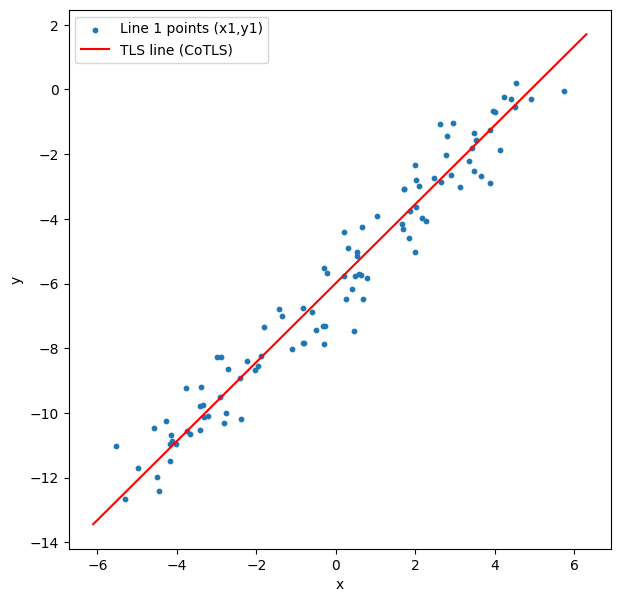

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

x = D[:, 0]  # x1
y = D[:, 3]  # y1

xbar = np.mean(x)
ybar = np.mean(y)

U = np.column_stack((x - xbar, y - ybar))   # Nx2

M = U.T @ U                                  # 2x2 symmetric matrix

eigvals, eigvecs = np.linalg.eigh(M)         # eigvals sorted ascending
a, b = eigvecs[:, 0]                         # smallest eigenvalue => index 0

norm = np.hypot(a, b)
a, b = a / norm, b / norm

d = a * xbar + b * ybar

print(f"Q1(a) TLS line parameters: a={a:.6f}, b={b:.6f}, d={d:.6f}")
print(f"Line equation: {a:.6f}x + {b:.6f}y = {d:.6f}")


fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x, y, s=10, label="Line 1 points (x1,y1)")

x_min, x_max = ax.get_xlim()
x_plot = np.array([x_min, x_max])

eps = 1e-12
if abs(b) < eps:
    # Vertical line: ax = d -> x = d/a
    ax.axvline(d / a, color="r", label="TLS line (vertical)")
else:
    # ax + by = d -> y = (d - a x)/b
    y_plot = (d - a * x_plot) / b
    ax.plot(x_plot, y_plot, "r-", label="TLS line (CoTLS)")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

Q1 (b)

In [ ]:
import numpy as np

# TLS (CoTLS) fit: ax + by = d, with a^2 + b^2 = 1
def tls_fit(points):
    x = points[:, 0]
    y = points[:, 1]
    xbar, ybar = np.mean(x), np.mean(y)

    U = np.column_stack((x - xbar, y - ybar))   # centered matrix (Nx2)
    M = U.T @ U                                 # 2x2 scatter matrix

    eigvals, eigvecs = np.linalg.eigh(M)        # ascending eigenvalues
    a, b = eigvecs[:, 0]                        # smallest eigenvalue eigenvector

    # normalize: a^2 + b^2 = 1
    norm = np.hypot(a, b)
    a, b = a / norm, b / norm

    d = a * xbar + b * ybar

    # optional sign convention (for consistent reporting)
    if b < 0:
        a, b, d = -a, -b, -d

    return a, b, d

def line_from_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = x2 - x1, y2 - y1
    norm = np.hypot(dx, dy)
    if norm < 1e-12:
        return None

    # unit normal to direction (dx,dy) is (dy, -dx) / ||(dx,dy)||
    a = dy / norm
    b = -dx / norm
    d = a * x1 + b * y1

    # (a,b) is already unit-length
    if b < 0:
        a, b, d = -a, -b, -d

    return a, b, d

def point_line_distance(points, model):
    a, b, d = model
    return np.abs(a * points[:, 0] + b * points[:, 1] - d)  # since (a,b) unit

# RANSAC to find ONE line
def ransac_one_line(points, n_iter=20000, threshold=0.7, seed=0):
    rng = np.random.default_rng(seed)
    N = len(points)

    best_inliers = None
    best_model = None
    best_count = -1

    for _ in range(n_iter):
        i, j = rng.integers(0, N, size=2)
        if i == j:
            continue

        model = line_from_two_points(points[i], points[j])
        if model is None:
            continue

        dist = point_line_distance(points, model)
        inliers = dist < threshold
        count = int(inliers.sum())

        if count > best_count:
            best_count = count
            best_inliers = inliers
            best_model = model

    # refine with TLS on inliers
    refined = tls_fit(points[best_inliers])

    # recompute inliers using refined model
    dist = point_line_distance(points, refined)
    inliers = dist < threshold

    # final TLS refine on updated inliers
    refined = tls_fit(points[inliers])

    return refined, inliers

# Q1(b): load & flatten all points (exactly as given)

D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

points_all = np.column_stack((X_all, Y_all))   # (300,2)

# Find 3 lines by RANSAC + masking (hint)
threshold = 0.2      
n_iter = 1000
seed = 20

remaining = points_all.copy()
models = []

for k in range(3):
    model, inliers = ransac_one_line(remaining, n_iter=n_iter, threshold=threshold, seed=seed + k)
    models.append(model)
    remaining = remaining[~inliers]  # mask consensus and run again

# (Recommended) Assign ALL points to nearest model and refit TLS
# This prevents early masking from stealing points from other lines.
dist_mat = np.column_stack([point_line_distance(points_all, m) for m in models])
labels = np.argmin(dist_mat, axis=1)

final_models = []
for k in range(3):
    final_models.append(tls_fit(points_all[labels == k]))

print("Final line parameters (a, b, d):")
for i, (a, b, d) in enumerate(final_models, 1):
    print(f"Line {i}: a={a:.6f}, b={b:.6f}, d={d:.6f}")


Final line parameters (a, b, d):
Line 1: a=0.435822, b=0.900033, d=1.901225
Line 2: a=-0.718179, b=0.695859, d=0.666156
Line 3: a=-0.772887, b=0.634543, d=-3.802590
